# 🧠 Deep Learning: Image Classification with CNN — CIFAR-10

**Author:** Sebastian Lopez  
**Date:** February 2026  
**Environment:** Python 3.10 | TensorFlow 2.18.1 | Keras 3.6.0  
**Dataset:** CIFAR-10 (60,000 images, 10 classes, 32×32 RGB)

---

## 📋 Project Overview

This notebook builds and evaluates **two deep learning models** for classifying images from the CIFAR-10 dataset into 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

**Models developed:**
1. **Custom CNN** — A purpose-built convolutional neural network with 3 convolutional blocks
2. **MobileNetV2 Transfer Learning** — Leveraging pretrained ImageNet features with fine-tuning

**Assessment Components Covered:**
| # | Component | Section |
|---|-----------|---------|
| 1 | Data Preprocessing | §2–3 |
| 2 | Model Architecture | §4 |
| 3 | Model Training | §5 |
| 4 | Model Evaluation | §6 |
| 5 | Transfer Learning | §7 |
| 6 | Code Quality | Throughout |
| 7 | Report & Analysis | §8–9 |
| 8 | Model Deployment | §10 |

---
## 1. Setup & Imports

First, we install/import all required libraries. This notebook is **fully self-contained** — no external project modules needed.

In [36]:
%matplotlib inline

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from keras.api.datasets import cifar10
from keras.api.utils import to_categorical
from keras.api.models import Sequential, Model
from keras.api.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Flatten,
    BatchNormalization, GlobalAveragePooling2D, Input, UpSampling2D
)
from keras.api.applications import MobileNetV2
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.src.legacy.preprocessing.image import ImageDataGenerator

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
np.random.seed(42)
tf.random.set_seed(42)

# Constants
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10
IMG_SHAPE = (32, 32, 3)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.18.1
Keras version: 3.6.0
NumPy version: 2.0.1
GPU available: False


---
## 2. Data Loading & Exploration

The **CIFAR-10** dataset contains 60,000 color images (32×32 pixels) in 10 balanced classes:
- **Training set:** 50,000 images
- **Test set:** 10,000 images

Each pixel has 3 channels (RGB) with values ranging from 0 to 255.

> **Why check the data first?** Understanding the shape, distribution, and scale of your data is critical. CIFAR-10 is balanced, which means accuracy is a fair evaluation metric.

In [37]:
# Load the CIFAR-10 dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

print("=" * 50)
print("  CIFAR-10 Dataset Summary")
print("=" * 50)

print(f"  Training images: {x_train_raw.shape[0]:,}")
print(f"  Test images:     {x_test_raw.shape[0]:,}")
print(f"  Image shape:     {x_train_raw.shape[1:]}")
print(f"  Pixel range:     [{x_train_raw.min()}, {x_train_raw.max()}]")
print(f"  Data type:       {x_train_raw.dtype}")
print(f"  Classes:         {NUM_CLASSES}")
print(f"  Class names:     {', '.join(CLASS_NAMES)}")

  CIFAR-10 Dataset Summary
  Training images: 50,000
  Test images:     10,000
  Image shape:     (32, 32, 3)
  Pixel range:     [0, 255]
  Data type:       uint8
  Classes:         10
  Class names:     airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


### 2.1 Sample Images

Let's visualize a random selection of images to understand what the model will learn to classify. Note how small 32×32 images are — even humans can find some of these challenging!

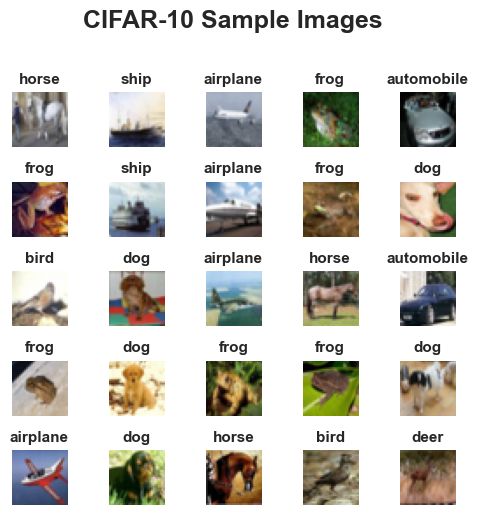

In [38]:
# Display 25 random sample images
fig, axes = plt.subplots(5, 5, figsize=(5, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=18, fontweight='bold', y=1.02)

indices = np.random.choice(len(x_train_raw), 25, replace=False)
labels = y_train_raw.flatten()

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(x_train_raw[idx])
    ax.set_title(CLASS_NAMES[labels[idx]], fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2.2 Class Distribution

A balanced dataset means each class has roughly the same number of images. This is important because it ensures accuracy is a fair metric — no class is over- or under-represented.

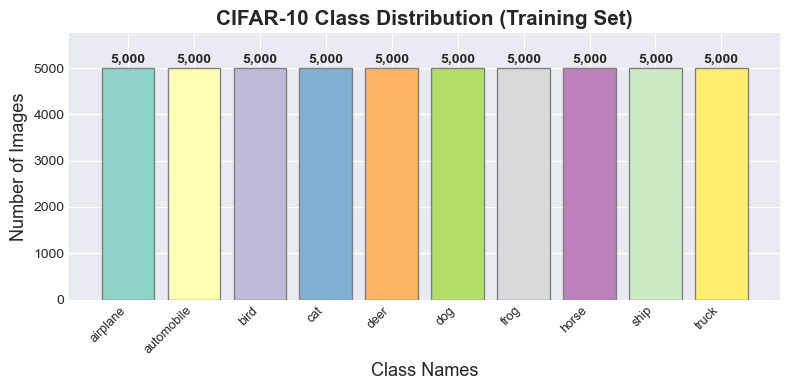


 Dataset is perfectly balanced: 5,000 images per class


In [39]:
# Plot class distribution
labels = y_train_raw.flatten()
unique, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Set3(np.linspace(0, 1, len(CLASS_NAMES)))
bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='gray')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Class Names', fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('CIFAR-10 Class Distribution (Training Set)', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n Dataset is perfectly balanced: {counts[0]:,} images per class")

---
## 3. Data Preprocessing

### 3.1 Normalization

We scale pixel values from **[0, 255] → [0.0, 1.0]** by dividing by 255. This ensures:
- Consistent gradient magnitudes during backpropagation
- Faster and more stable convergence
- Prevention of large values dominating weight updates

### 3.2 One-Hot Encoding

Integer labels (e.g., `3` for "cat") are converted to 10-dimensional binary vectors:
- `3` → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

This is required for `categorical_crossentropy` loss, which expects probability distributions.

### 3.3 Train/Validation Split

- **Training:** 45,000 images (90%)
- **Validation:** 5,000 images (10%)
- **Test:** 10,000 images (held-out)

In [40]:
# 1. Normalize pixel values to [0, 1]
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# 2. One-hot encode labels
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test = to_categorical(y_test_raw, NUM_CLASSES)

# 3. Create train/validation split
val_split = 0.1
split_idx = int(len(x_train) * (1 - val_split))
x_val = x_train[split_idx:]
y_val = y_train[split_idx:]
x_train_split = x_train[:split_idx]
y_train_split = y_train[:split_idx]


print(f"  x_train range:  [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"  y_train shape:  {y_train.shape} (one-hot encoding)")
print(f"  Train split:    {x_train_split.shape[0]:,} images")
print(f"  Validation:     {x_val.shape[0]:,} images")
print(f"  Test:           {x_test.shape[0]:,} images")

  x_train range:  [0.0, 1.0]
  y_train shape:  (50000, 10) (one-hot encoding)
  Train split:    45,000 images
  Validation:     5,000 images
  Test:           10,000 images


### 3.4 Data Augmentation

Data augmentation artificially increases dataset diversity by applying random transformations during training. 

**Purpose:** combats overfitting —> the model learns from varied perspectives instead of memorizing specific images.

| Augmentation       | Range       | Purpose |
|:-------------------|:------------|:--------|
| Rotation           | ±15°        | Rotation invariance |
| Width/Height shift | ±10%        | Translation invariance |
| Horizontal flip    | Random      | Mirror invariance |
| Zoom               | ±10%        | Scale invariance |


**Important:** Augmentation is applied **only to training data**, never to validation/test sets. We need clean, unmodified data for honest evaluation.

 
 IMPORTANT:Augmentation creates diverse training samples from each original image



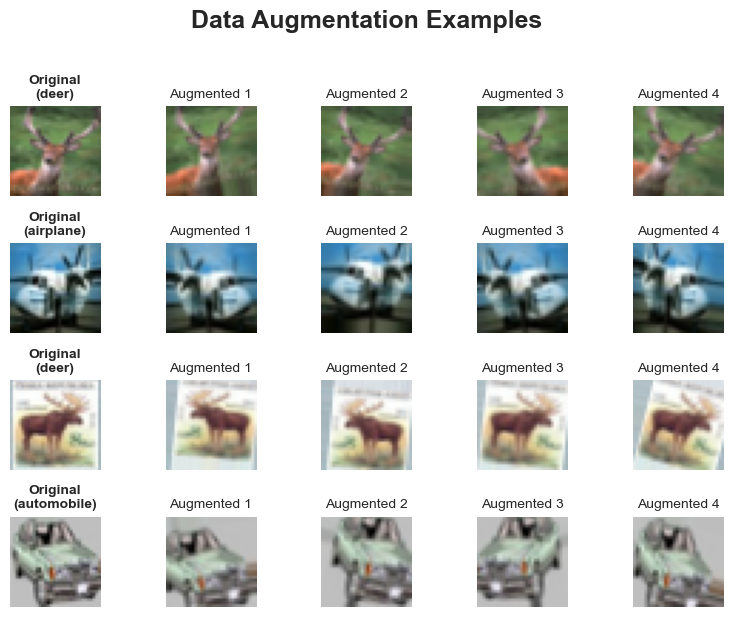

In [41]:
print(" \n IMPORTANT:Augmentation creates diverse training samples from each original image\n")

# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
datagen.fit(x_train_split)

# Visualize augmentation examples
fig, axes = plt.subplots(4, 5, figsize=(8, 6))
fig.suptitle('Data Augmentation Examples', fontsize=18, fontweight='bold', y=1.02)

sample_indices = np.random.choice(len(x_train_split), 4, replace=False)

for row, idx in enumerate(sample_indices):
    original = x_train_split[idx]
    label_idx = np.argmax(y_train_split[idx])

    # Show original
    axes[row, 0].imshow(np.clip(original, 0, 1))
    axes[row, 0].set_title(f'Original\n({CLASS_NAMES[label_idx]})', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

    # Show augmented versions
    img_batch = np.expand_dims(original, axis=0)
    aug_iter = datagen.flow(img_batch, batch_size=1)
    for col in range(1, 5):
        aug_img = next(aug_iter)[0]
        axes[row, col].imshow(np.clip(aug_img, 0, 1))
        axes[row, col].set_title(f'Augmented {col}', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


---
## 4. Custom CNN Architecture

### Architecture Design

A **3-block convolutional network** designed for 32×32 CIFAR-10 images:

```
Block 1: Conv2D(32) × 2 → BatchNorm → MaxPool(2×2) → Dropout(0.25)
Block 2: Conv2D(64) × 2 → BatchNorm → MaxPool(2×2) → Dropout(0.25)
Block 3: Conv2D(128) × 2 → BatchNorm → MaxPool(2×2) → Dropout(0.25)
Head:    Flatten → Dense(256) → BatchNorm → Dropout(0.5) → Dense(10, softmax)
```

**Design rationale:**
- **Progressive filter increase** (32→64→128): Early layers detect simple features (edges, textures); deeper layers capture complex patterns (eyes, wheels, wings)
- **BatchNormalization**: Stabilizes training by normalizing activations between layers
- **Dropout at every block**: Strong regularization to prevent overfitting
- **`padding='same'`**: Preserves spatial dimensions within each convolutional block

In [42]:
def build_custom_cnn(input_shape=IMG_SHAPE, num_classes=NUM_CLASSES):
    """
    Build a custom CNN architecture.
    
    Architecture:
        Block 1: Conv2D(32) -> BatchNorm -> Conv2D(32) -> BatchNorm -> MaxPool -> Dropout(0.25)
        Block 2: Conv2D(64) -> BatchNorm -> Conv2D(64) -> BatchNorm -> MaxPool -> Dropout(0.25)
        Block 3: Conv2D(128) -> BatchNorm -> Conv2D(128) -> BatchNorm -> MaxPool -> Dropout(0.25)
        Dense: Flatten -> Dense(256) -> BatchNorm -> Dropout(0.5) -> Dense(10, softmax)

    Takeaway: there are 23 Layers total (including activations and normalizations)
    """
    model = Sequential([
        # --- Block 1: 32 filters ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # --- Block 2: 64 filters ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # --- Block 3: 128 filters ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # --- Classifier head ---
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Build and compile the model
custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
custom_cnn.summary()

/opt/miniconda3/envs/ironhack.nn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

---
## 5. Training the Custom CNN

### Training Configuration

| Parameter | Value | Rationale |
|:----------|:------|:----------|
| Optimizer | Adam | Adaptive learning rates, good default |
| Learning rate | 0.001 | Standard starting point for Adam |
| Batch size | 64 | Balance between speed and gradient quality |
| Max epochs | 100 | Early stopping will intervene before this |
| Data augmentation | Yes | Reduces overfitting on training set |

### Callbacks

- **EarlyStopping** (`patience=10`): Stops training when validation loss stops improving for 10 epochs. Restores the best weights automatically.
- **ReduceLROnPlateau** (`factor=0.5, patience=5`): Halves the learning rate when validation loss plateaus, helping escape local minima.
- **ModelCheckpoint**: Saves the best model (lowest validation loss) to disk.

> 🫟 **Training took ~17h** in my hardware. i skiiped because a pre-trained model exists in models 🗂️ folder

In [43]:
# Training configuration
BATCH_SIZE = 64
EPOCHS = 100
MODEL_SAVE_DIR = 'models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
CUSTOM_CNN_PATH = os.path.join(MODEL_SAVE_DIR, 'custom_cnn.keras')

# Define callbacks
callbacks_custom = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CUSTOM_CNN_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured:")
print("   EarlyStopping (patience=10, restore_best_weights=True)")
print("   ModelCheckpoint (save_best_only=True)")
print("   ReduceLROnPlateau (factor=0.5, patience=5)")

Callbacks configured:
   EarlyStopping (patience=10, restore_best_weights=True)
   ModelCheckpoint (save_best_only=True)
   ReduceLROnPlateau (factor=0.5, patience=5)


### 🫟 **Training took ~17h** in my hardware. i skiiped because a pre-trained model exists in models 🗂️ folder

In [44]:
""" 
%%time
# Train the custom CNN with data augmentation

history_custom = custom_cnn.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=callbacks_custom,
    steps_per_epoch=len(x_train_split) // BATCH_SIZE,
    verbose=1
)
""" 

' \n%%time\n# Train the custom CNN with data augmentation\n\nhistory_custom = custom_cnn.fit(\n    datagen.flow(x_train_split, y_train_split, batch_size=BATCH_SIZE),\n    epochs=EPOCHS,\n    validation_data=(x_val, y_val),\n    callbacks=callbacks_custom,\n    steps_per_epoch=len(x_train_split) // BATCH_SIZE,\n    verbose=1\n)\n'

## Pre-trained model in models 🗂️ Folder

#### OPCION 1 - With verification

In [45]:
# Load pre-trained models
""" import os
    from tensorflow import keras--- IGNORE ---"""

MODEL_DIR = '/Users/sebastianlopez/Desktop/it-studies/ironhack/week_7/day_2/models'
CUSTOM_CNN_PATH = os.path.join(MODEL_DIR, 'custom_cnn.keras')
TRANSFER_LEARNING_PATH = os.path.join(MODEL_DIR, 'transfer_learning.keras')

# Load the Custom CNN model
if os.path.exists(CUSTOM_CNN_PATH):
    custom_cnn = keras.models.load_model(CUSTOM_CNN_PATH)
    print(f"✅ Loaded pre-trained Custom CNN model from {CUSTOM_CNN_PATH}")
else:
    print(f"❌ Custom CNN model not found at {CUSTOM_CNN_PATH}. Please train the model or check the path.")


✅ Loaded pre-trained Custom CNN model from /Users/sebastianlopez/Desktop/it-studies/ironhack/week_7/day_2/models/custom_cnn.keras


#### OPCION 2 - Faster 

In [46]:
from tensorflow import keras
custom_cnn = keras.models.load_model('/Users/sebastianlopez/Desktop/it-studies/ironhack/week_7/day_2/models/custom_cnn.keras')

---
## 6. Model Evaluation — Custom CNN

### Evaluation Metrics

- **Accuracy**: Overall percentage of correct predictions
- **Precision**: Of all predictions for class X, how many were correct? (avoids false positives)
- **Recall**: Of all actual class X samples, how many were found? (avoids false negatives)
- **F1-Score**: Harmonic mean of precision and recall — a balanced single metric
- **Confusion Matrix**: Grid showing true vs. predicted labels for every class pair

In [ ]:
def evaluate_and_report(model, x_test, y_test, model_name='Model'):
    """Evaluate model and return metrics dictionary with full report."""
    # Get test loss and accuracy
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    
    # Get predictions
    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Compute metrics
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
    
    # Print summary
    
    print(f"  {model_name} — Evaluation Results")
   
    print(f"  Test Loss:      {loss:.4f}")
    print(f"  Test Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall:         {rec:.4f}")
    print(f"  F1-Score:       {f1:.4f}")
    print(f"{'='*60}")
    print(f"\nClassification Report:\n")
    print(report)
    
    return {
        'loss': loss, 'accuracy': accuracy, 'precision': prec,
        'recall': rec, 'f1_score': f1, 'y_true': y_true, 'y_pred': y_pred
    }

# Evaluate Custom CNN
metrics_custom = evaluate_and_report(custom_cnn, x_test, y_test, 'Custom CNN')

  Custom CNN — Evaluation Results
  Test Loss:      0.4460
  Test Accuracy:  0.8530  (85.30%)
  Precision:      0.8556
  Recall:         0.8530
  F1-Score:       0.8512

Classification Report:

              precision    recall  f1-score   support

    airplane       0.89      0.84      0.86      1000
  automobile       0.89      0.96      0.92      1000
        bird       0.86      0.75      0.80      1000
         cat       0.81      0.65      0.72      1000
        deer       0.82      0.86      0.84      1000
         dog       0.82      0.77      0.80      1000
        frog       0.74      0.97      0.84      1000
       horse       0.90      0.90      0.90      1000
        ship       0.94      0.91      0.92      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



In [59]:
# NameError: name 'history_custom' is not defined 
# Run just if the model was trained inthis jupyter 

""" 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# --- Gráfico de Exactitud (Accuracy) ---
axes[0].plot(history_custom.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_custom.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Custom CNN Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# --- Gráfico de Pérdida (Loss) ---
axes[1].plot(history_custom.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_custom.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Custom CNN Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
"""

" \nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n# --- Gráfico de Exactitud (Accuracy) ---\naxes[0].plot(history_custom.history['accuracy'], label='Train Accuracy', linewidth=2)\naxes[0].plot(history_custom.history['val_accuracy'], label='Validation Accuracy', linewidth=2)\naxes[0].set_title('Custom CNN Accuracy', fontsize=14)\naxes[0].set_xlabel('Epoch')\naxes[0].set_ylabel('Accuracy')\naxes[0].legend()\naxes[0].grid(True, alpha=0.3)\n# --- Gráfico de Pérdida (Loss) ---\naxes[1].plot(history_custom.history['loss'], label='Train Loss', linewidth=2)\naxes[1].plot(history_custom.history['val_loss'], label='Validation Loss', linewidth=2)\naxes[1].set_title('Custom CNN Loss', fontsize=14)\naxes[1].set_xlabel('Epoch')\naxes[1].set_ylabel('Loss')\naxes[1].legend()\naxes[1].grid(True, alpha=0.3)\nplt.tight_layout()\n\nplt.show()\n"

#### CUSTON CNN TRAINING
![Custom CNN Training](/Users/sebastianlopez/Desktop/it-studies/ironhack/week_7/day_2/outputs/custom_cnn_history.png)

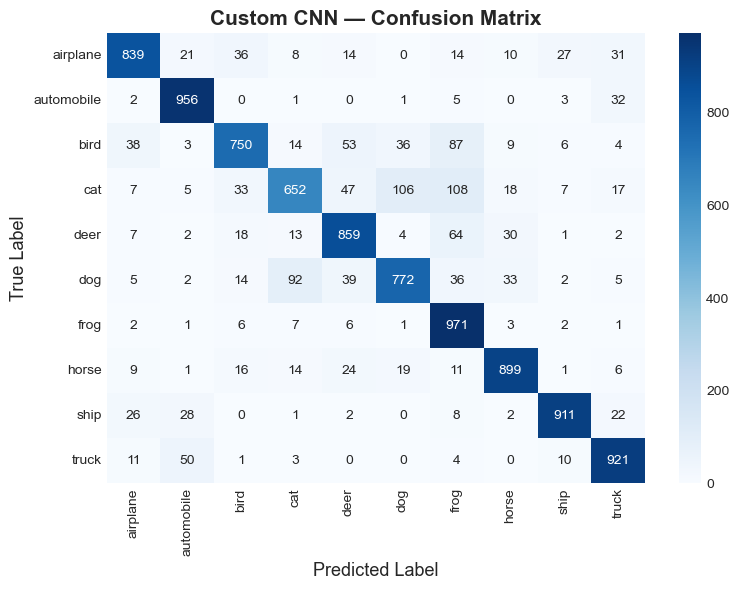


🔍 Most confused pair: cat ↔ frog (108 not match)


In [48]:
# Confusion Matrix
cm = confusion_matrix(metrics_custom['y_true'], metrics_custom['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Custom CNN — Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify most confused pairs
np.fill_diagonal(cm, 0)
max_idx = np.unravel_index(cm.argmax(), cm.shape)
print(f"\n🔍 Most confused pair: {CLASS_NAMES[max_idx[0]]} ↔ {CLASS_NAMES[max_idx[1]]} ({cm[max_idx]} not match)")

# 7. Training model Transfer learning ResNet50

#### 1: Load the Base Model and Freeze It

In [ ]:
from keras.applications import ResNet50
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D

# 1. Load the pre-trained ResNet50 model
# 'weights=imagenet' downloads the pre-trained knowledge.
# 'include_top=False' chops off the original 1000-class output layer.
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. FREEZE the base model 
# This is the most crucial step of Transfer Learning!
# We want to use its existing knowledge, not overwrite it.
resnet_base.trainable = False 
print("Base model loaded and frozen!")

In [ ]:
# 3. Build our customized Transfer Learning Model
transfer_model = Sequential([
    resnet_base,                             # The frozen ResNet50 layers
    GlobalAveragePooling2D(),                # Safely flattens the output of ResNet50
    Dense(256, activation='relu'),           # Our new "thinking" layer
    Dense(10, activation='softmax')          # Our 10 outputs for CIFAR-10 classification
])
# 4. Compile the model
# NOTE: If your Y labels are NOT one-hot encoded, change 'categorical_crossentropy' to 'sparse_categorical_crossentropy'
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)
transfer_model.summary()

In [ ]:
# 5. Train the model!
# Documentation says we can use fewer epochs because the base model already knows how to "see" images.

history_tl = transfer_model.fit(
    X_train, y_train,     # Use whatever variables you used for the custom CNN training
    validation_split=0.2, 
    epochs=10, 
    batch_size=64
)